In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

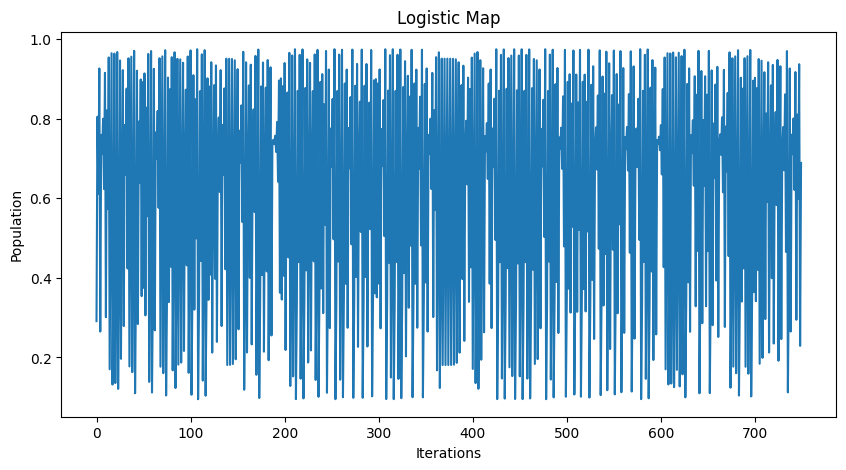

In [24]:
#A.2 Logistic Map

def logistic_map(r, x):
    return r * x * (1 - x)

r = 3.9
x0 = 0.5
iterations = 1000

x = np.zeros(iterations)
x[0] = x0

for i in range(iterations - 1):
    x[i + 1] = logistic_map(r, x[i])



plt.figure(figsize=(10, 5))
plt.plot(x[250:])
plt.title("Logistic Map")
plt.xlabel("Iterations")
plt.ylabel("Population")
plt.show()

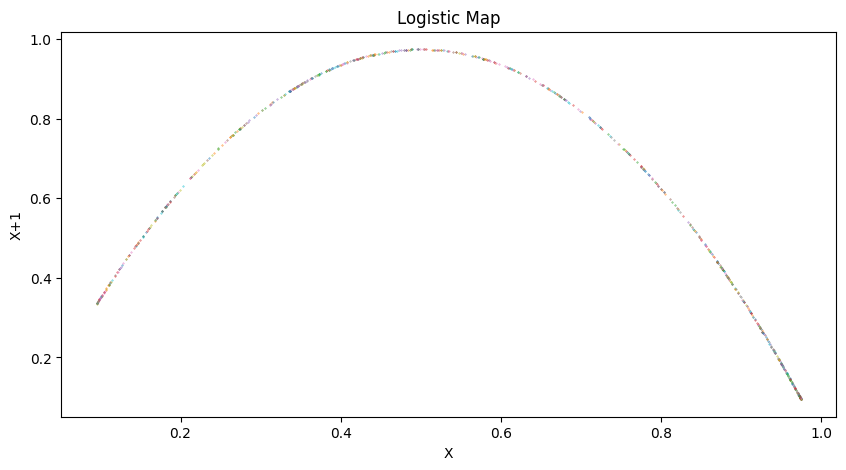

In [26]:
plt.figure(figsize=(10, 5))
for i in range(999-250):
    plt.scatter(x[i+250], x[i+250+1], s=0.1)
plt.title("Logistic Map")
plt.xlabel("X")
plt.ylabel("X+1")
plt.show()

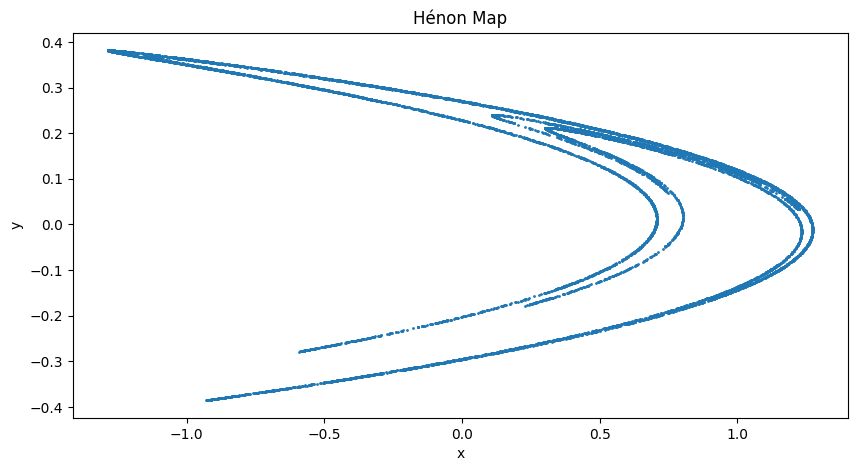

In [ ]:
#A.3 Hénon Map
def henon_map(x, y, a, b):
    x_new = 1 - a*x**2 + y
    y_new = b*x
    return x_new, y_new

a = 1.4
b = 0.3
iterations = 10000

x = np.zeros(iterations)
y = np.zeros(iterations)

x[0] = 0
y[0] = 0

for i in range(iterations - 1):
    x[i + 1], y[i + 1] = henon_map(x[i], y[i], a, b)

plt.figure(figsize=(10, 5))
plt.scatter(x[500:], y[500:], s=1)
plt.title("Hénon Map")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

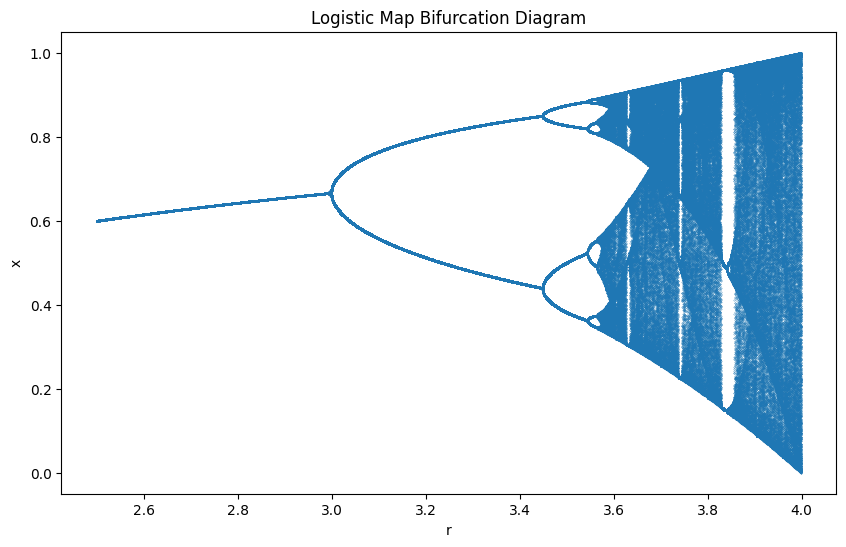

In [20]:
# A.4 Bifurcation Diagram
r_values = np.arange(2.5, 4.0, 0.001)

r_plot = []
x_plot = []

iterations = 1000
transient = 500

for r in r_values:

    x = 0.5

    for i in range(iterations):

        x = logistic_map(r, x)

        if i >= transient:
            r_plot.append(r)
            x_plot.append(x)

plt.figure(figsize=(10,6))
plt.scatter(r_plot, x_plot, s=0.05)
plt.xlabel("r")
plt.ylabel("x")
plt.title("Logistic Map Bifurcation Diagram")
plt.show()

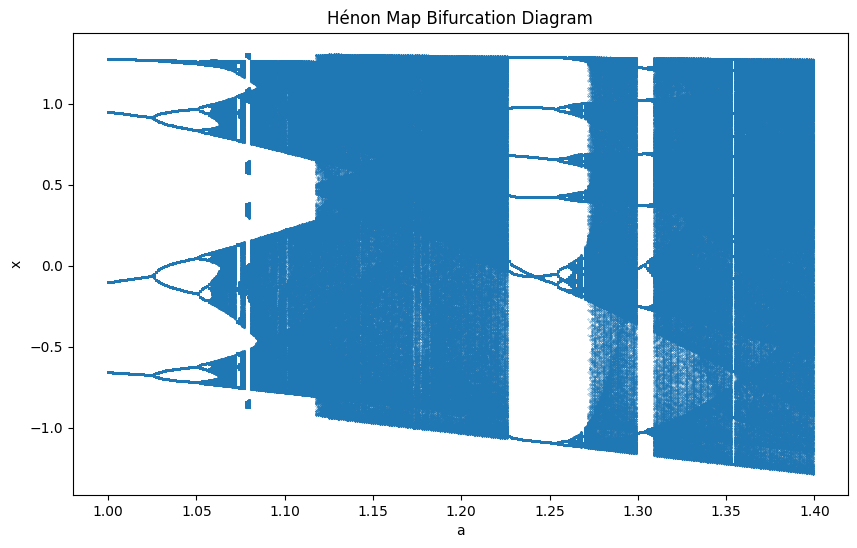

In [21]:
a_values = np.arange(1.0, 1.4, 0.001)

a_plot = []
x_plot = []

for a in a_values:

    x = 0
    y = 0

    for i in range(5000):

        x, y = henon_map(x, y, a, 0.3)

        if i >= 500:
            a_plot.append(a)
            x_plot.append(x)

plt.figure(figsize=(10, 6))
plt.scatter(a_plot, x_plot, s=0.05)
plt.xlabel("a")
plt.ylabel("x")
plt.title("Hénon Map Bifurcation Diagram")
plt.show()

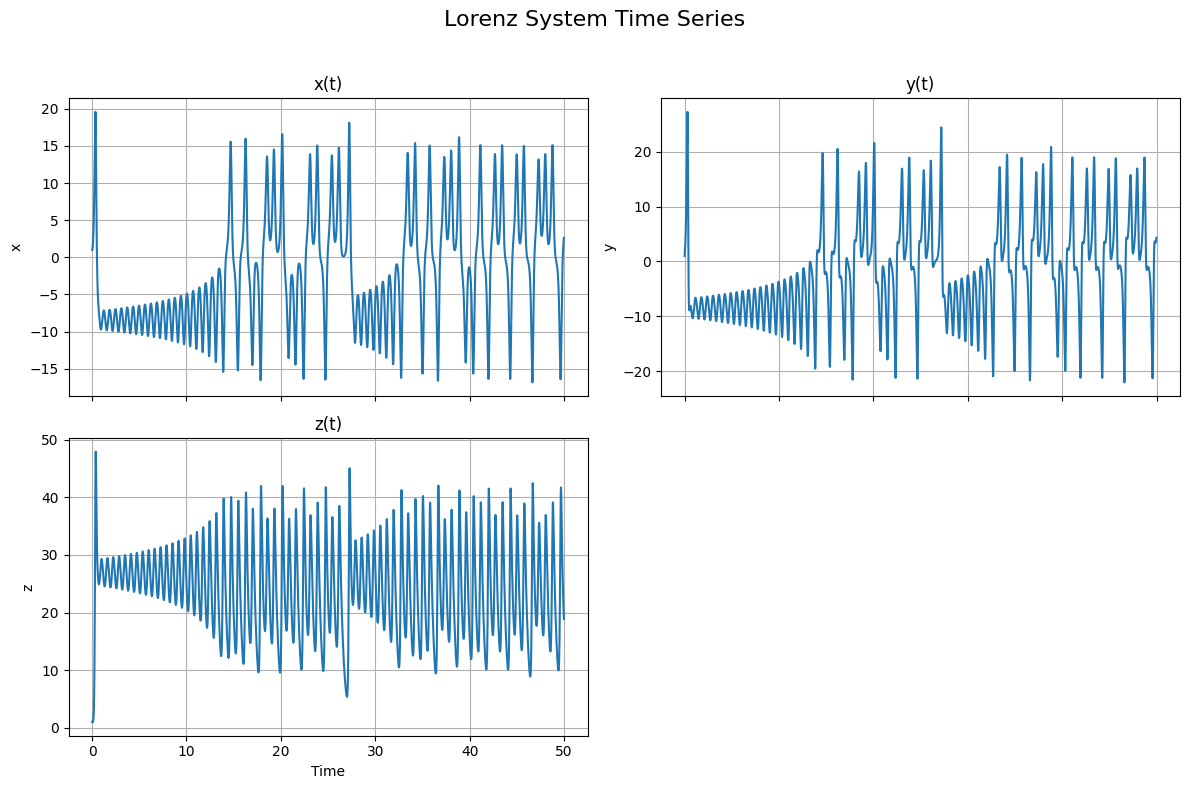

In [ ]:
# B.2 Lorenz System
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return [dx, dy, dz]


T = 50
dt = 0.01

t = np.arange(0, T, dt)

initial_state = [1, 1, 1]

solution = solve_ivp(lorenz, [0, T], initial_state, t_eval=t)

x = solution.y[0]
y = solution.y[1]
z = solution.y[2]




fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axs[0, 0].plot(t, x)
axs[0, 0].set_title("x(t)")
axs[0, 0].set_ylabel("x")
axs[0, 0].grid(True)

axs[0, 1].plot(t, y)
axs[0, 1].set_title("y(t)")
axs[0, 1].set_ylabel("y")
axs[0, 1].grid(True)

axs[1, 0].plot(t, z)
axs[1, 0].set_title("z(t)")
axs[1, 0].set_xlabel("Time")
axs[1, 0].set_ylabel("z")
axs[1, 0].grid(True)

fig.delaxes(axs[1, 1])

plt.suptitle("Lorenz System Time Series", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

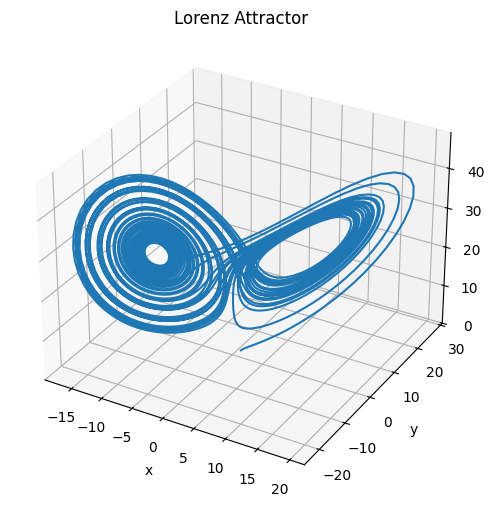

In [7]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz Attractor")

plt.show()

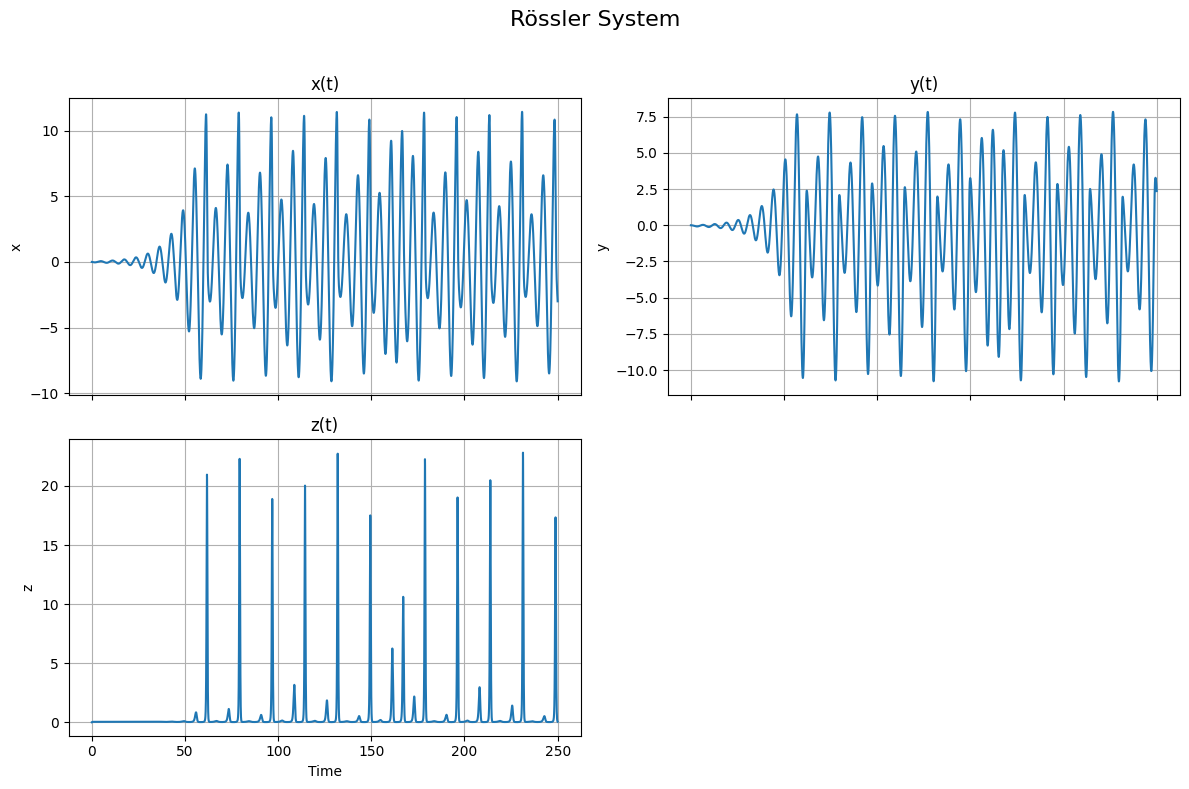

In [18]:
# B.3 Rössler System

def rossler(t, state, a=0.2, b=0.2, c=5.7):

    x, y, z = state

    dx = -y - z
    dy = x + a*y
    dz = b + z*(x-c)

    return [dx, dy, dz]


T = 250
dt = 0.01

t = np.arange(0, T, dt)

initial_state = [0,0,0]

solution = solve_ivp(rossler,[0,T],initial_state,t_eval=t)

x = solution.y[0]
y = solution.y[1]
z = solution.y[2]


fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axs[0, 0].plot(t, x)
axs[0, 0].set_title("x(t)")
axs[0, 0].set_ylabel("x")
axs[0, 0].grid(True)

axs[0, 1].plot(t, y)
axs[0, 1].set_title("y(t)")
axs[0, 1].set_ylabel("y")
axs[0, 1].grid(True)

axs[1, 0].plot(t, z)
axs[1, 0].set_title("z(t)")
axs[1, 0].set_xlabel("Time")
axs[1, 0].set_ylabel("z")
axs[1, 0].grid(True)

fig.delaxes(axs[1, 1])

plt.suptitle("Rössler System", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

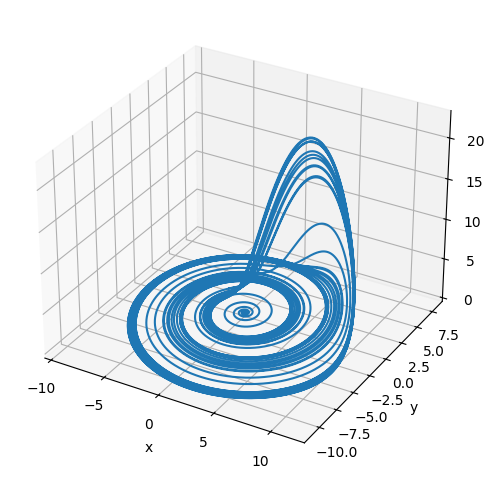

In [9]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x,y,z)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

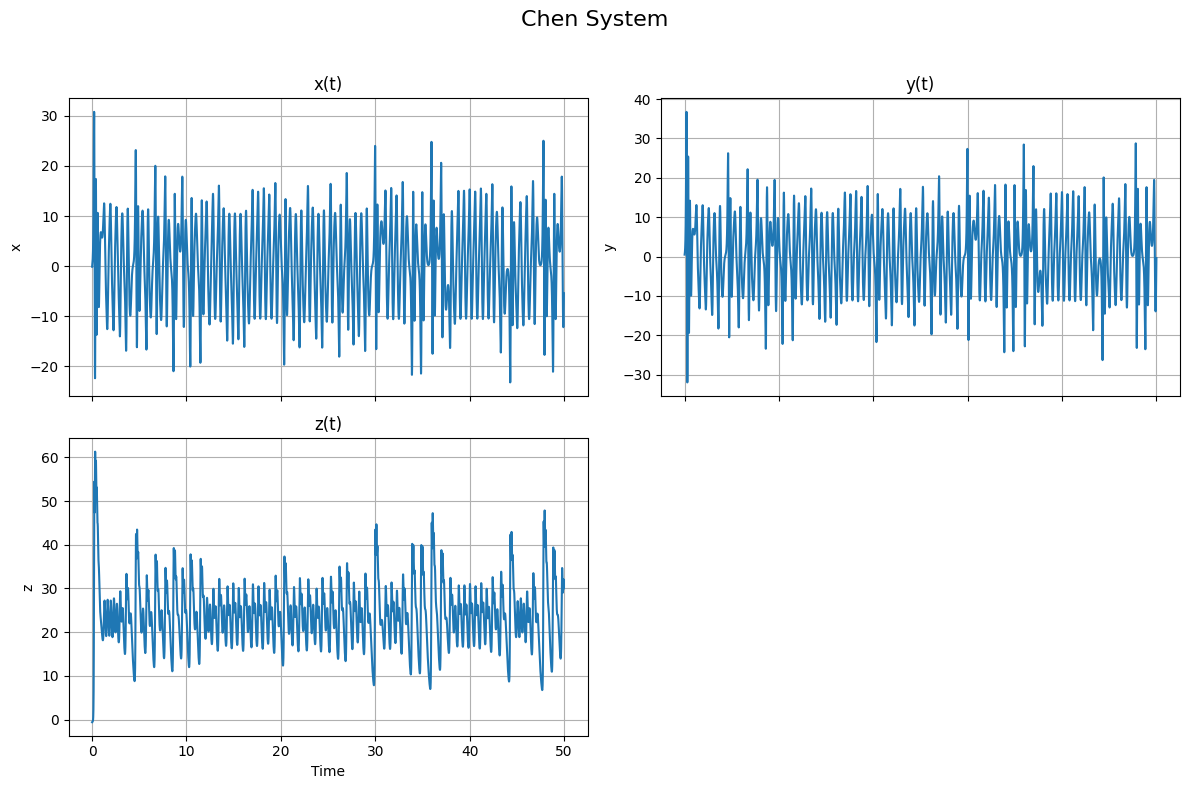

In [19]:
#B.4 Chen System
def chen(t, state, a=35, b=3, c=28):

    x, y, z = state

    dx = a*(y-x)
    dy = (c-a)*x - x*z + c*y
    dz = x*y - b*z

    return [dx,dy,dz]


T = 50
dt = 0.003

t = np.arange(0, T, dt)

initial_state = [-0.1,0.5,-0.6]

solution = solve_ivp(chen,[0,T],initial_state,t_eval=t)

x = solution.y[0]
y = solution.y[1]
z = solution.y[2]


fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axs[0, 0].plot(t, x)
axs[0, 0].set_title("x(t)")
axs[0, 0].set_ylabel("x")
axs[0, 0].grid(True)

axs[0, 1].plot(t, y)
axs[0, 1].set_title("y(t)")
axs[0, 1].set_ylabel("y")
axs[0, 1].grid(True)

axs[1, 0].plot(t, z)
axs[1, 0].set_title("z(t)")
axs[1, 0].set_xlabel("Time")
axs[1, 0].set_ylabel("z")
axs[1, 0].grid(True)

fig.delaxes(axs[1, 1])

plt.suptitle("Chen System", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

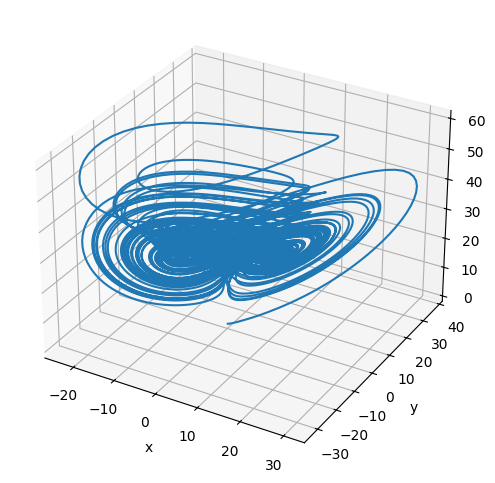

In [11]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.plot(x,y,z)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

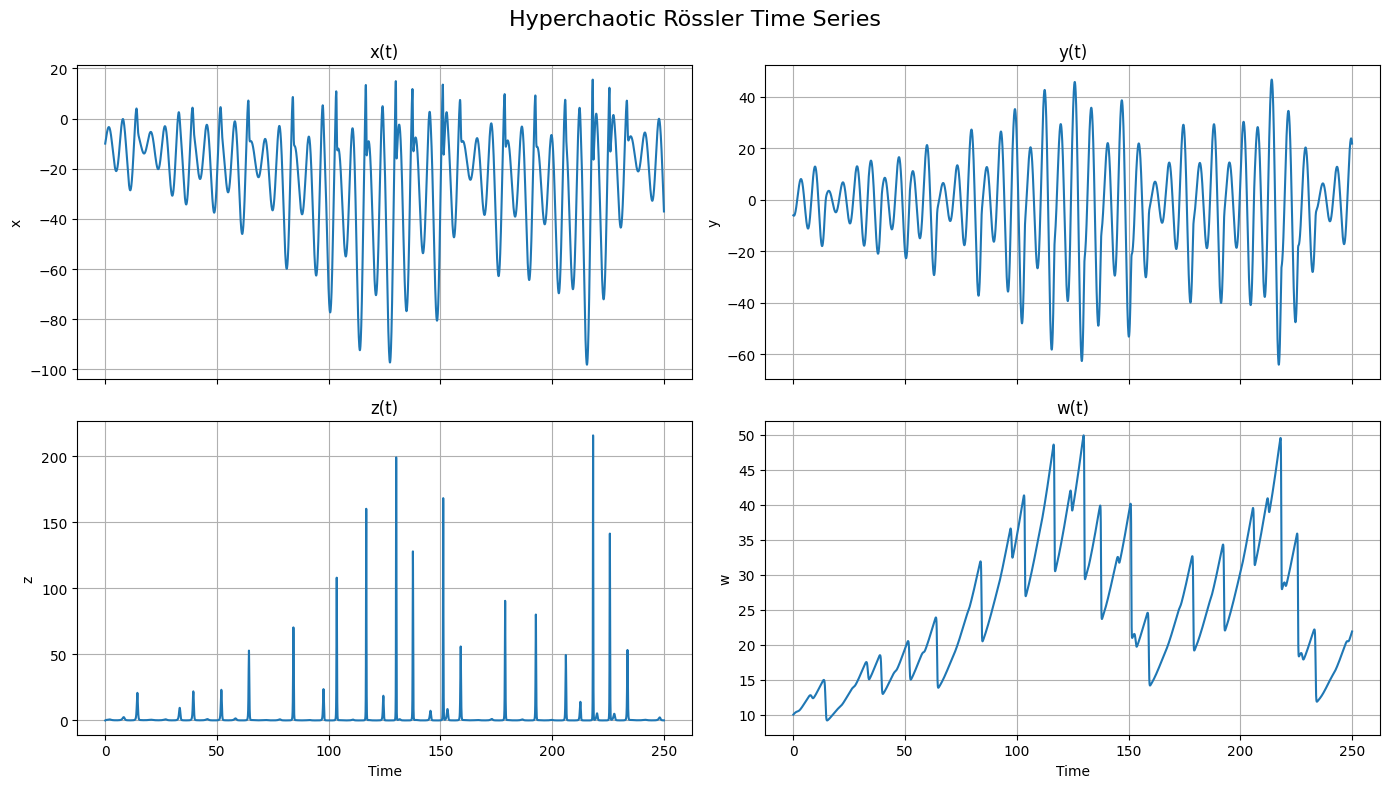

In [15]:
# B.5 Hyperchaotic Rössler System
def hyper_rossler(t, state, a=0.25, b=3, c=0.5, d=0.05):

    x, y, z, w = state

    dx = -y - z
    dy = x + a*y + w
    dz = b + x*z
    dw = -c*z + d*w

    return [dx,dy,dz,dw]

T = 250
dt = 0.01

t = np.arange(0,T,dt)

initial_state = [-10,-6,0,10]

solution = solve_ivp(hyper_rossler, [0,T], initial_state, t_eval=t)

x = solution.y[0]
y = solution.y[1]
z = solution.y[2]
w = solution.y[3]


fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
# x(t)
axs[0, 0].plot(t, x)
axs[0, 0].set_title("x(t)")
axs[0, 0].set_ylabel("x")
axs[0, 0].grid(True)

# y(t)
axs[0, 1].plot(t, y)
axs[0, 1].set_title("y(t)")
axs[0, 1].set_ylabel("y")
axs[0, 1].grid(True)

# z(t)
axs[1, 0].plot(t, z)
axs[1, 0].set_title("z(t)")
axs[1, 0].set_xlabel("Time")
axs[1, 0].set_ylabel("z")
axs[1, 0].grid(True)

# w(t)
axs[1, 1].plot(t, w)
axs[1, 1].set_title("w(t)")
axs[1, 1].set_xlabel("Time")
axs[1, 1].set_ylabel("w")
axs[1, 1].grid(True)

plt.suptitle("Hyperchaotic Rössler Time Series", fontsize=16)

plt.tight_layout()
plt.show()

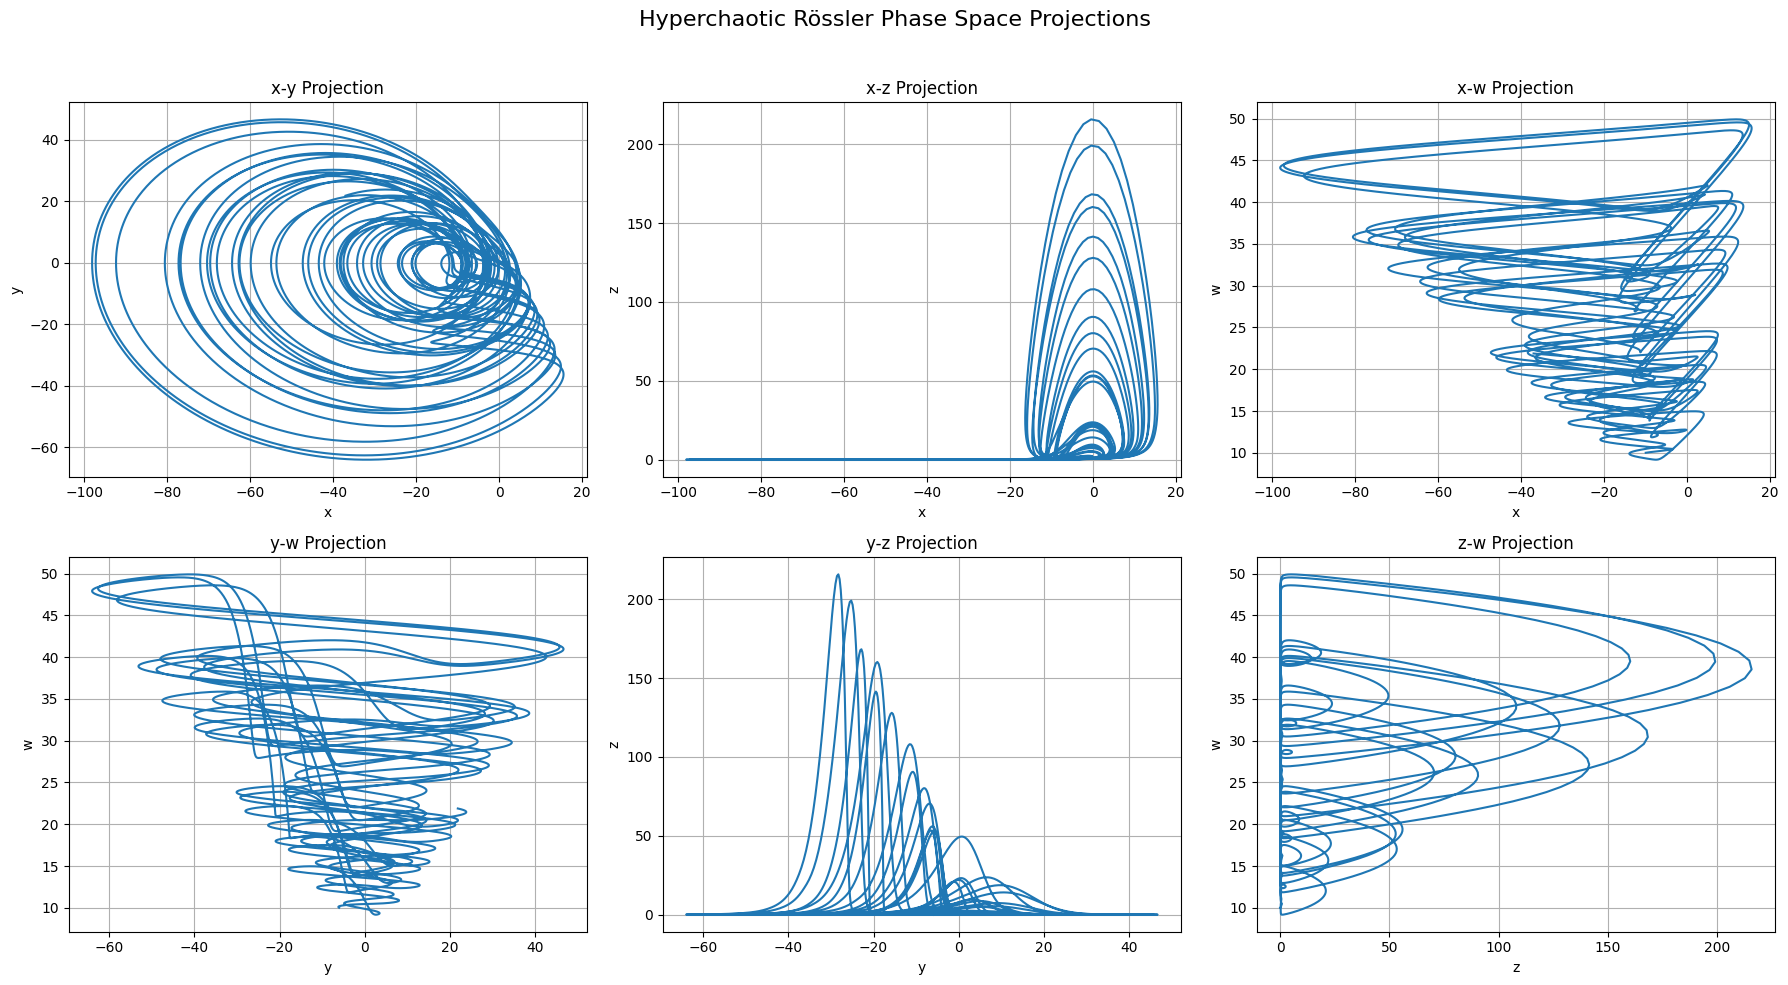

In [16]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
# x-y
axs[0, 0].plot(x, y)
axs[0, 0].set_title("x-y Projection")
axs[0, 0].set_xlabel("x")
axs[0, 0].set_ylabel("y")
axs[0, 0].grid(True)

# x-z
axs[0, 1].plot(x, z)
axs[0, 1].set_title("x-z Projection")
axs[0, 1].set_xlabel("x")
axs[0, 1].set_ylabel("z")
axs[0, 1].grid(True)

# x-w
axs[0, 2].plot(x, w)
axs[0, 2].set_title("x-w Projection")
axs[0, 2].set_xlabel("x")
axs[0, 2].set_ylabel("w")
axs[0, 2].grid(True)

# y-w
axs[1, 0].plot(y, w)
axs[1, 0].set_title("y-w Projection")
axs[1, 0].set_xlabel("y")
axs[1, 0].set_ylabel("w")
axs[1, 0].grid(True)

# y-z
axs[1, 1].plot(y, z)
axs[1, 1].set_title("y-z Projection")
axs[1, 1].set_xlabel("y")
axs[1, 1].set_ylabel("z")
axs[1, 1].grid(True)

# z-w
axs[1, 2].plot(z, w)
axs[1, 2].set_title("z-w Projection")
axs[1, 2].set_xlabel("z")
axs[1, 2].set_ylabel("w")
axs[1, 2].grid(True)

plt.suptitle("Hyperchaotic Rössler Phase Space Projections", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

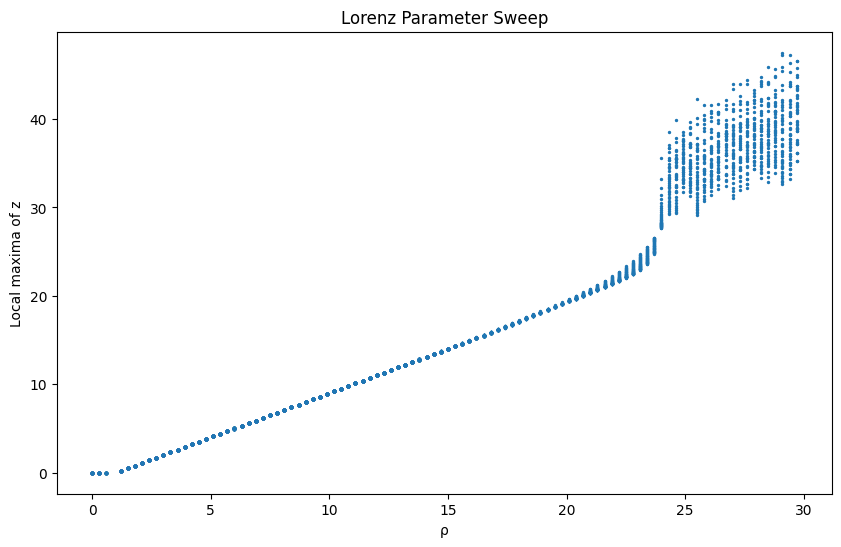

In [20]:
# C.1
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return [dx, dy, dz]

rho_values = np.arange(0, 30, 0.3)

rho_plot = []
z_plot = []

T = 50
dt = 0.01

t = np.arange(0, T, dt)

initial_state = [1, 1, 1]

for rho in rho_values:
    solution = solve_ivp(lorenz, [0, 50], initial_state, args=(10, rho, 8/3), t_eval=t)

    z = solution.y[2]
    t = solution.t

    z = z[t >= 20]

    for i in range(1, len(z)-1):
        if z[i] > z[i-1] and z[i] > z[i+1]:
            rho_plot.append(rho)
            z_plot.append(z[i])


plt.figure(figsize=(10,6))
plt.scatter(rho_plot, z_plot, s=2)
plt.xlabel("ρ")
plt.ylabel("Local maxima of z")
plt.title("Lorenz Parameter Sweep")
plt.show()

In [25]:
# C.2
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return [dx, dy, dz]

def simulate(dt):
    t = np.arange(0,50,dt)
    solution = solve_ivp(lorenz, [0,50], [1,1,1], max_step=dt, t_eval=t)
    return t, solution.y


t1, s1 = simulate(0.001)
t2, s2 = simulate(0.01)
t3, s3 = simulate(0.05)




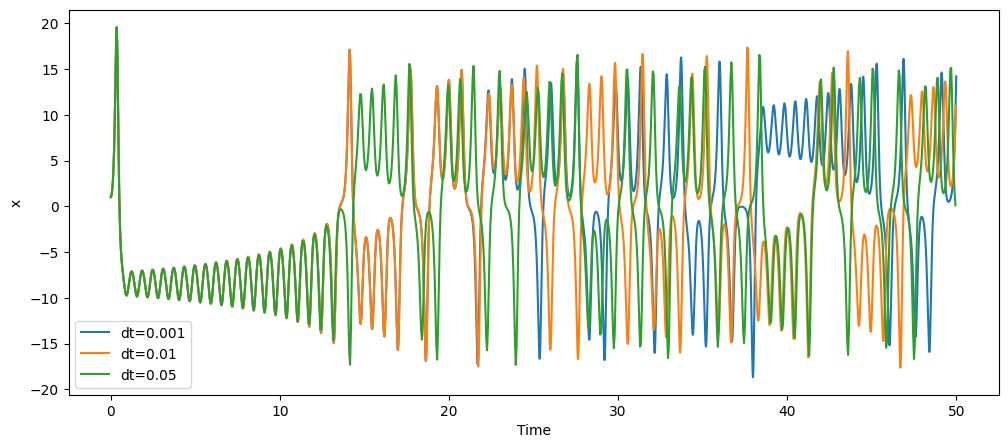

In [26]:
plt.figure(figsize=(12,5))
plt.plot(t1, s1[0], label='dt=0.001')
plt.plot(t2, s2[0], label='dt=0.01')
plt.plot(t3, s3[0], label='dt=0.05')
plt.legend()
plt.xlabel("Time")
plt.ylabel("x")
plt.show()

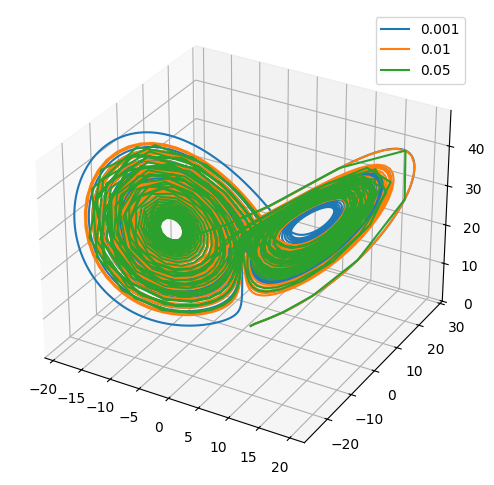

In [27]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(s1[0], s1[1], s1[2], label='0.001')
ax.plot(s2[0], s2[1], s2[2], label='0.01')
ax.plot(s3[0], s3[1], s3[2], label='0.05')
ax.legend()
plt.show()

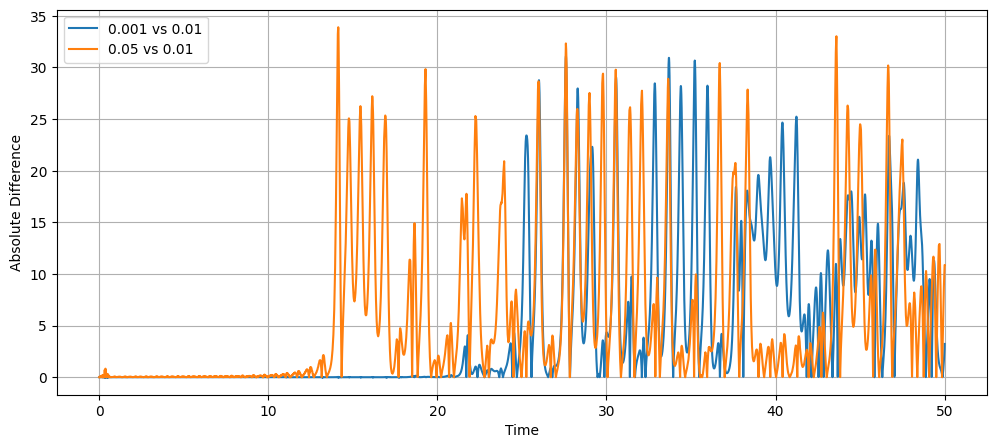

In [29]:
x_baseline = np.interp(t1, t2, s2[0])
x_coarse = np.interp(t1, t3, s3[0])

div_fine = np.abs(s1[0] - x_baseline)
div_coarse = np.abs(x_coarse - x_baseline)

plt.figure(figsize=(12,5))

plt.plot(t1, div_fine, label="0.001 vs 0.01")
plt.plot(t1, div_coarse, label="0.05 vs 0.01")

plt.xlabel("Time")
plt.ylabel("Absolute Difference")
plt.legend()
plt.grid(True)

plt.show()